# 01 — Explore FRED

First look at the data layer: confirm credentials load, see the shape of the series manifest, exercise every `fred_client.py` function, and eyeball the three core series before any modelling starts.

## 1. Load `.env`

Only the *presence* and length of each key are shown below.

In [1]:
import os

from dotenv import load_dotenv

load_dotenv()

for key_name in ["FRED_API_KEY", "EIA_API_KEY"]:
    value = os.environ.get(key_name)
    status = f"set (length={len(value)})" if value else "MISSING"
    print(f"{key_name}: {status}")

FRED_API_KEY: set (length=32)
EIA_API_KEY: set (length=40)


## 2. Series manifest as a DataFrame

The shape of the data this project pulls from FRED, before pulling any of it.

In [2]:
import pandas as pd

from src.series_manifest import SERIES

manifest_df = pd.DataFrame.from_dict(SERIES, orient="index").rename_axis("series_id").reset_index()
manifest_df

,series_id,kind,freq,role,benchmark,fuel,hub,formulation,region
0,WCOILWTICO,crude,weekly-fri,core,WTI,NaN,NaN,NaN,NaN
1,DCOILWTICO,crude,daily,core,WTI,NaN,NaN,NaN,NaN
2,WCOILBRENTEU,crude,weekly-fri,robustness,Brent,NaN,NaN,NaN,NaN
3,DCOILBRENTEU,crude,daily,robustness,Brent,NaN,NaN,NaN,NaN
4,WGASUSGULF,spot,weekly-fri,core,NaN,gasoline,Gulf Coast,conventional,NaN
5,DGASUSGULF,spot,daily,core,NaN,gasoline,Gulf Coast,conventional,NaN
6,WGASNYH,spot,weekly-fri,regional,NaN,gasoline,NY Harbor,conventional,NaN
7,DGASNYH,spot,daily,regional,NaN,gasoline,NY Harbor,conventional,NaN
8,WRGASLA,spot,weekly-fri,regional,NaN,gasoline,Los Angeles,RBOB,NaN
9,DRGASLA,spot,daily,regional,NaN,gasoline,Los Angeles,RBOB,NaN


In [3]:
print("--- by kind ---")
print(manifest_df["kind"].value_counts())
print("\n--- by freq ---")
print(manifest_df["freq"].value_counts())
print("\n--- by role ---")
print(manifest_df["role"].value_counts())

--- by kind ---
kind
retail    13
spot      12
crude      4
Name: count, dtype: int64

--- by freq ---
freq
weekly-mon    13
weekly-fri     8
daily          8
Name: count, dtype: int64

--- by role ---
role
placebo       12
regional       9
core           5
robustness     3
Name: count, dtype: int64


## 3. Exercise every `fred_client.py` function

One at a time: the call, then `.head()`, `.dtypes`, `.shape`, and the min/max date, for whichever of those actually apply to what the function returns.

### 3a. `get_series` — one series' observations

In [4]:
from IPython.display import display
from src.fred_client import get_series

wti = get_series("WCOILWTICO")
print(f"WTI shape: {wti.shape}")
print(f"Types:\n{wti.dtypes}")
print(f"Date range: {wti['date'].min().date()} to {wti['date'].max().date()}")
display(wti.head())


WTI shape: (2117, 2)
Types:
date     datetime64[us]
value           float64
dtype: object
Date range: 1986-01-03 to 2026-07-24


,date,value
0,1986-01-03,25.78
1,1986-01-10,25.99
2,1986-01-17,24.57
3,1986-01-24,20.31
4,1986-01-31,19.69


### 3b. `list_release_series` — every series in a FRED release

Release 212 ("Petroleum and Other Liquids") — the wholesale-spot release this project draws from.

In [5]:
from src.fred_client import list_release_series

release_212 = list_release_series(212)

print(f"Release 212 shape: {release_212.shape}")
print(f"Types:\n{release_212.dtypes}")
# No single "date" column here — the closest equivalent is the earliest observation_start
# and latest observation_end across every series the release contains.
print(f"Date range:\nobservation_start min: {release_212['observation_start'].min()}\nobservation_end max:   {release_212['observation_end'].max()}")

Release 212 shape: (44, 5)
Types:
series_id            str
title                str
frequency            str
observation_start    str
observation_end      str
dtype: object
Date range:
observation_start min: 1986-01-01
observation_end max:   2026-07-27


In [6]:
release_212.head()

,series_id,title,frequency,observation_start,observation_end
0,ACOILBRENTEU,Crude Oil Prices: Brent - Europe,Annual,1987-01-01,2025-01-01
1,ACOILWTICO,Crude Oil Prices: West Texas Intermediate (WTI...,Annual,1986-01-01,2025-01-01
2,ADFUELLA,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: Los...,Annual,2001-01-01,2025-01-01
3,ADFUELNYH,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: New...,Annual,2006-01-01,2025-01-01
4,ADFUELUSGULF,Ultra-Low-Sulfur No. 2 Diesel Fuel Prices: U.S...,Annual,2006-01-01,2025-01-01


### 3c. `get_series_info` — one series' metadata

Returns a raw single series' metadata `dict` for test purposes, not a `DataFrame`.

In [7]:
from src.fred_client import get_series_info

get_series_info("WCOILWTICO")

{'id': 'WCOILWTICO',
 'realtime_start': '2026-07-31',
 'realtime_end': '2026-07-31',
 'title': 'Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma',
 'observation_start': '1986-01-03',
 'observation_end': '2026-07-24',
 'frequency': 'Weekly, Ending Friday',
 'frequency_short': 'W',
 'units': 'Dollars per Barrel',
 'units_short': '$ per Barrel',
 'seasonal_adjustment': 'Not Seasonally Adjusted',
 'seasonal_adjustment_short': 'NSA',
 'last_updated': '2026-07-29 12:17:16-05',
 'popularity': 41,
 'notes': 'Definitions, Sources and Explanatory Notes: http://www.eia.doe.gov/dnav/pet/TblDefs/pet_pri_spt_tbldef2.asp'}

## 4. The three core series

`WCOILWTICO` (crude), `WGASUSGULF` (wholesale spot gasoline), `GASREGW` (retail gasoline) — the core slots in the transmission chain. Last 5 rows of each, plus a day-of-week check: crude and wholesale spot should land on Fridays, retail on Mondays.

In [8]:
from src.fred_client import get_series

core_series = {
    "WCOILWTICO": wti,  # already pulled in §3a — no need to re-fetch
    "WGASUSGULF": get_series("WGASUSGULF"),
    "GASREGW": get_series("GASREGW"),
}

for series_id, df in core_series.items():
    print(f"--- {series_id} ---\n\tlast 5 rows:")
    display(df.tail())
    print(f"\n\tday-of-week counts:")
    print(df["date"].dt.day_name().value_counts(), "\n")

--- WCOILWTICO ---
	last 5 rows:


,date,value
2112,2026-06-26,73.59
2113,2026-07-03,70.48
2114,2026-07-10,72.26
2115,2026-07-17,80.77
2116,2026-07-24,88.58



	day-of-week counts:
date
Friday    2117
Name: count, dtype: int64 

--- WGASUSGULF ---
	last 5 rows:


,date,value
2090,2026-06-26,2.966
2091,2026-07-03,3.038
2092,2026-07-10,3.038
2093,2026-07-17,3.266
2094,2026-07-24,3.490



	day-of-week counts:
date
Friday    2095
Name: count, dtype: int64 

--- GASREGW ---
	last 5 rows:


,date,value
1871,2026-06-29,3.831
1872,2026-07-06,3.777
1873,2026-07-13,3.855
1874,2026-07-20,4.001
1875,2026-07-27,4.096



	day-of-week counts:
date
Monday    1876
Name: count, dtype: int64 



## 5. Crude vs. gasoline, 2010 → now

Two panels, different native units — crude in \$/barrel, gasoline (wholesale spot and retail) in \$/gallon. To get just a first look not converted to a common unit here.

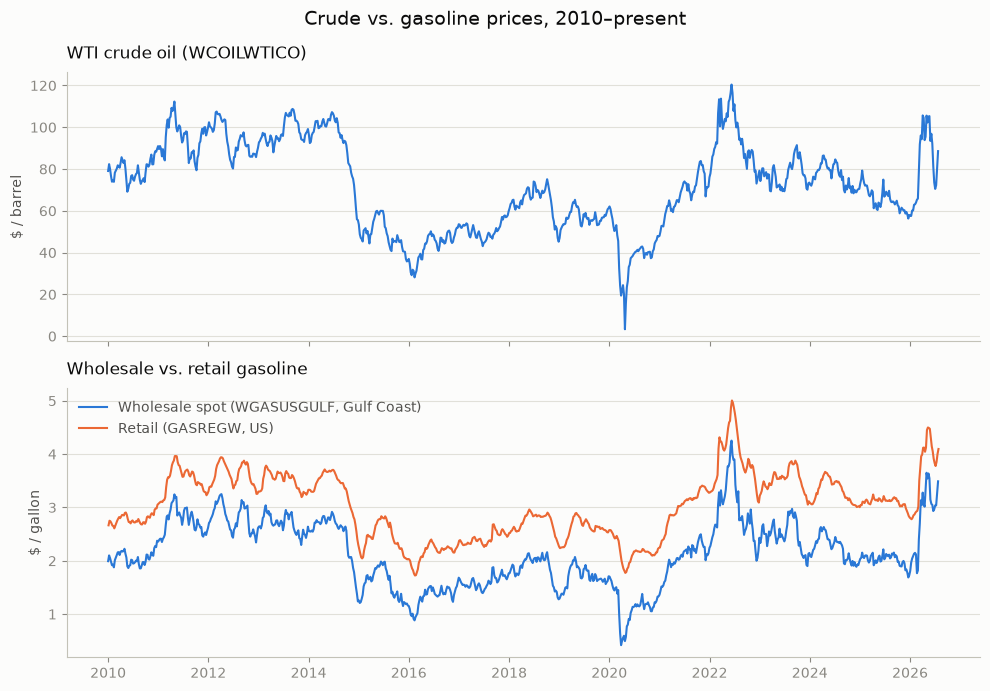

In [9]:
import matplotlib.pyplot as plt

PLOT_START = "2010-01-01"

crude = core_series["WCOILWTICO"]
crude = crude[crude["date"] >= PLOT_START]
wholesale = core_series["WGASUSGULF"]
wholesale = wholesale[wholesale["date"] >= PLOT_START]
retail = core_series["GASREGW"]
retail = retail[retail["date"] >= PLOT_START]

fig, (ax_crude, ax_gas) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, facecolor="#fcfcfb")

for ax in (ax_crude, ax_gas):
    ax.set_facecolor("#fcfcfb")
    ax.tick_params(colors="#898781")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#c3c2b7")
    ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

ax_crude.plot(crude["date"], crude["value"], color="#2a78d6", linewidth=1.5)
ax_crude.set_title("WTI crude oil (WCOILWTICO)", color="#0b0b0b", fontsize=12, pad=10, loc="left")
ax_crude.set_ylabel("$ / barrel", color="#52514e")

ax_gas.plot(wholesale["date"], wholesale["value"], color="#2a78d6", linewidth=1.5, label="Wholesale spot (WGASUSGULF, Gulf Coast)")
ax_gas.plot(retail["date"], retail["value"], color="#eb6834", linewidth=1.5, label="Retail (GASREGW, US)")
ax_gas.set_title("Wholesale vs. retail gasoline", color="#0b0b0b", fontsize=12, pad=10, loc="left")
ax_gas.set_ylabel("$ / gallon", color="#52514e")
ax_gas.legend(frameon=False, labelcolor="#52514e")

fig.suptitle("Crude vs. gasoline prices, 2010\u2013present", color="#0b0b0b", fontsize=14)
plt.tight_layout()
plt.show()